In [2]:
# %pip install -q matplotlib 
# %pip install -q seaborn
# %pip install -q pandas
# %pip install -q numpy

In [64]:
import matplotlib.pyplot as plt 
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import os 
import re
from labellines import labelLines
import scipy.stats as stats

In [65]:
ior_results_dir_w = "../ior_results/write_only"
ior_results_dir_rw = "../ior_results/write_then_read"
# for each csv in each dir
# take the highest bandwidth row
full = pd.DataFrame()
for dir_name in os.listdir(ior_results_dir_rw):
    dir_path = os.path.join(ior_results_dir_rw, dir_name)
    for file_name in os.listdir(dir_path):
        if file_name.endswith('.csv'): 
            file = os.path.join(dir_path, file_name)
            try:
                tmp = pd.read_csv(file)
                tmp['fromCSV'] = file_name
                tmp['segments'] = re.search(r'.*_seg-(\d+)_.*', file).group(1)
                tmpw = tmp[tmp['access']=='write']
                tmpr = tmp[tmp['access']=='read']
                # tmp = (tmp.iloc[tmp.idxmax(numeric_only=True)['bw(MiB/s)']].to_frame().T)
                tmpw = tmpw.loc[[tmpw['bw(MiB/s)'].idxmax()]].copy()
                tmpr = tmpr.loc[[tmpr['bw(MiB/s)'].idxmax()]].copy()
                full = pd.concat([full,tmpw, tmpr], ignore_index=True)
            except Exception as e:
                print(f"{file}: {e}")

In [66]:
print(full.columns)

Index(['access', 'bw(MiB/s)', 'IOPS', 'Latency', 'block(KiB)', 'xfer(KiB)',
       'open(s)', 'wr/rd(s)', 'close(s)', 'total(s)', 'numTasks', 'iter',
       'fromCSV', 'segments'],
      dtype='object')


In [67]:

full['segments'] = full['segments'].astype(int)
full['block(KiB)'] = full['block(KiB)'].astype(int)
full['xfer(KiB)'] = full['xfer(KiB)'].astype(int)
full['bw(GiB/s)'] =  full['bw(MiB/s)']/1024
full['numTasks'] = full['numTasks'].astype(int)
full['Latency(ms)'] = full['Latency']*1000
# fromCSV is the CSV's filename, formatted as <access>_n-<# nodes>_tx-<transfer size>.csv
full['nnodes'] = full['fromCSV'].str.extract(r'.*_n-(\d+)_.*')
full['nnodes'] = full['nnodes'].astype(int)
full = full.sort_values(by='nnodes')
# number of tasks, per node  as a column
full['tasks_per_node'] = full['numTasks']/full['nnodes']

# IOR_TX_SIZES=("16K" "1M" "2M" "16M")
xfer_map = {
    16:'16K',
    1024:'1M',
    2048:'2M',
    16384:'16M'
}
xfer_order = ["16K", "1M", "2M", "16M"]
full['xfer_str'] = full['xfer(KiB)'].map(xfer_map)


full.to_csv('../ior_results/ior_rw.csv')
print(full.columns)


readme_images = []
sns.set_style("whitegrid")

Index(['access', 'bw(MiB/s)', 'IOPS', 'Latency', 'block(KiB)', 'xfer(KiB)',
       'open(s)', 'wr/rd(s)', 'close(s)', 'total(s)', 'numTasks', 'iter',
       'fromCSV', 'segments', 'bw(GiB/s)', 'Latency(ms)', 'nnodes',
       'tasks_per_node', 'xfer_str'],
      dtype='object')


In [68]:
print(full['tasks_per_node'].value_counts())
print(full[(full['tasks_per_node'] == 6) & (full['access'] == 'write')])

tasks_per_node
16.0    48
8.0     48
32.0    48
48.0    48
6.0     48
Name: count, dtype: int64
    access     bw(MiB/s)          IOPS  Latency  block(KiB)  xfer(KiB)  \
14   write  3.285781e+04  2.064708e+03   0.0910      131072      16384   
30   write  1.409599e+04  1.412185e+04   0.0135      131072       1024   
32   write  6.713965e+02  4.297328e+04   0.0045      131072         16   
38   write  1.731822e+04  8.680443e+03   0.0219      131072       2048   
126  write  3.276787e+04  1.642107e+04   0.0234      131072       2048   
142  write  1.308294e+03  8.373810e+04   0.0046      131072         16   
138  write  2.684919e+04  2.689890e+04   0.0143      131072       1024   
152  write  6.613331e+04  4.154175e+03   0.0901      131072      16384   
84   write  5.524680e+04  5.535263e+04   0.0136      131072       1024   
80   write  6.678284e+04  3.347255e+04   0.0226      131072       2048   
96   write  1.322597e+05  8.308372e+03   0.0907      131072      16384   
90   write  2.64

# Bandwidth Plots

In [13]:
# x = "tasks_per_node"
# y = "Latency(ms)"
# hue = "xfer_str"
# hue_order = xfer_order

# df = full
# palette = sns.color_palette("magma", len(df[hue].unique()))

# for nodecount in full['nnodes'].unique():
#     df = full[full['nnodes']==nodecount]

#     g = sns.relplot(data=df,
#                     kind="line",
#                     x=x,
#                     y=y,
#                     hue=hue,
#                     hue_order=hue_order,
#                     col='access',
#                     col_order=['write', 'read'],
#                     palette=palette,
#                     marker='o',
#                     aspect=1.5,
#                     facet_kws={'legend_out': False}
#                     )
#     for ax in g.axes.flat:
#         # ax.legend(title="Transfer Size (bytes)")
#         ax.set_xticks(sorted(df[x].unique()))
        
#     g.set_xlabels("Number of Tasks per Node")
#     g.set_ylabels("Bandwidth (GiB/s)")
#     g.figure.suptitle(f"Write Bandwidth vs Tasks per Node with {nodecount}",  weight="bold", x = 0.5, y=1.01)
#     # plt.legend(title="Transfer Size (bytes)")

#     # img_path = ("graphs/ior_bandwidth/ior_bw_vs_nt_hue-xfer_col-n.svg")
#     # plt.savefig(img_path, bbox_inches="tight")
#     # readme_images.append(img_path)
#     plt.show()
#     plt.clf()

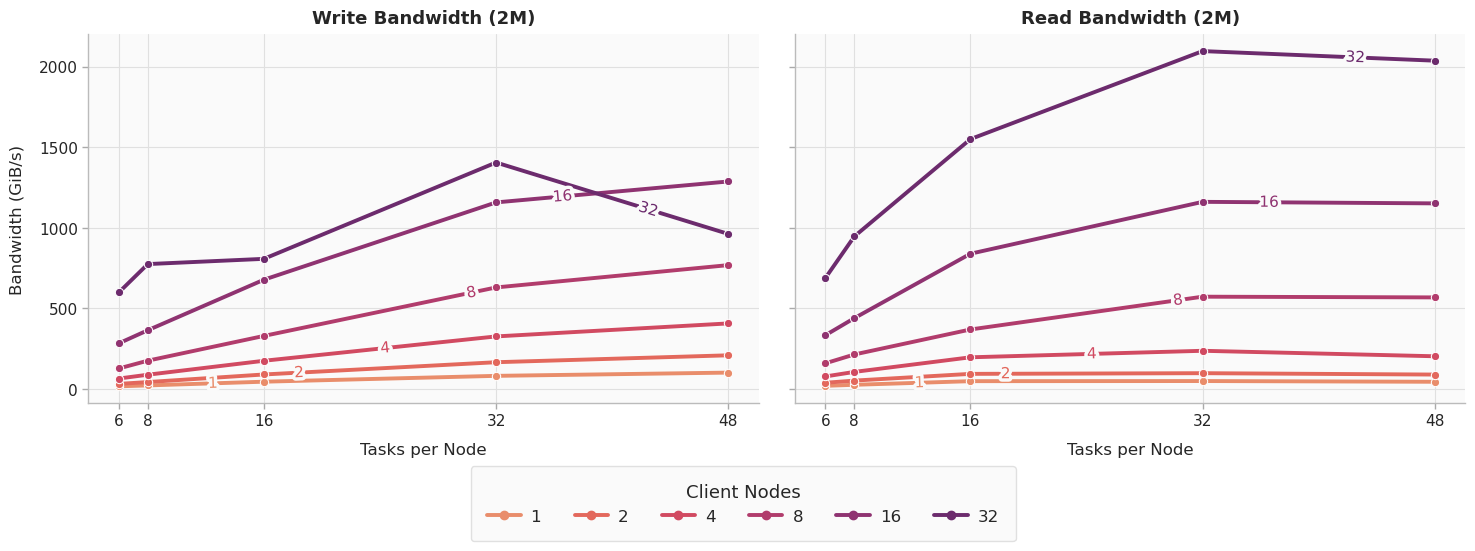

<Figure size 640x480 with 0 Axes>

In [36]:
x = "tasks_per_node"
y = "bw(GiB/s)"
hue = "nnodes"
xfer = "2M"

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              13,
    "axes.titlesize":         15,
    "axes.labelsize":         13,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        12,
    "legend.title_fontsize":  13,
    "lines.linewidth":        2.8,   # thicker lines read well at distance
})


df = full[(full['xfer_str']==xfer)]
palette = sns.color_palette("flare", len(df[hue].unique()))

col_titles = {"write": "Write Bandwidth (2M)", "read": "Read Bandwidth (2M)"}

g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                marker='o',
                facet_kws={'legend_out': False}
                )
for ax, access in zip(g.axes.flat, ["write", "read"]):

    ax.set_xticks(sorted(df[x].unique()))

    ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)

    hue_vals = sorted(df[hue].unique()) 
    lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
    for line, label in zip(lines, [str(v) for v in hue_vals]):
        line.set_label(label)
    labelLines(lines, fontsize=11, ha="left")

    # Lighten tick marks
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)


 
    
g.set_xlabels("Tasks per Node", fontsize=12, labelpad=10)
g.set_ylabels("Bandwidth (GiB/s)", fontsize=12, labelpad=10)
# g.figure.suptitle(f"Bandwidth vs Tasks per Node",  weight="bold", x = 0.5, y=1.1)
# g.figure.text(
#     0.5, 1.0,
#     f"Transfer size: {xfer}",
#     fontsize=14,
#     fontstyle="italic",
#     color="#555555",
#     ha="center",
#     va="bottom",
#     transform=g.figure.transFigure,
# )

sns.move_legend(
    g,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.15),
    # bbox_to_anchor=(1.0, 0.5),
    title="Client Nodes",
    frameon=True,
    framealpha=0.9,
    edgecolor="#dddddd",
    borderpad=1.0,
    handlelength=2.0,
    handletextpad=0.6,
)

g.figure.subplots_adjust(top=0.88)
img_path = ("../poster/diagrams/ior_bw-vs-tasks_hue-nodes-2M.svg")
plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

r (correlation coefficient):  (np.float64(0.7158799054432045), 5)
p-value:  (np.float64(1.0687367719770085e-08), 5)


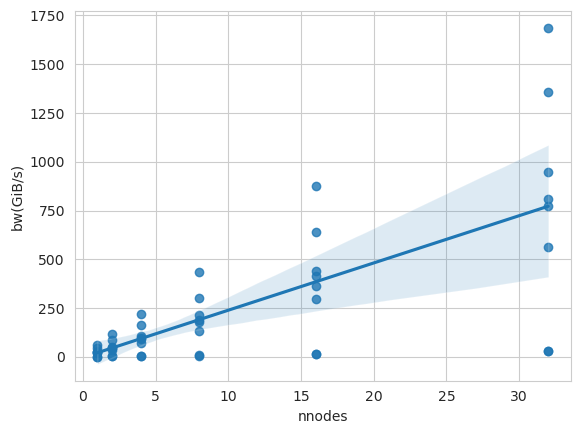

In [ ]:
# Does bandwidth have a linear relationship with number of nodes?
df = full[full['tasks_per_node'] == 8]
sns.regplot(x = "nnodes", y = "bw(GiB/s)", data = df)
res = stats.pearsonr(df['nnodes'], df['bw(GiB/s)'])
print("r (correlation coefficient): ", (res[0],5))
print("p-value: ", (res[1],5))



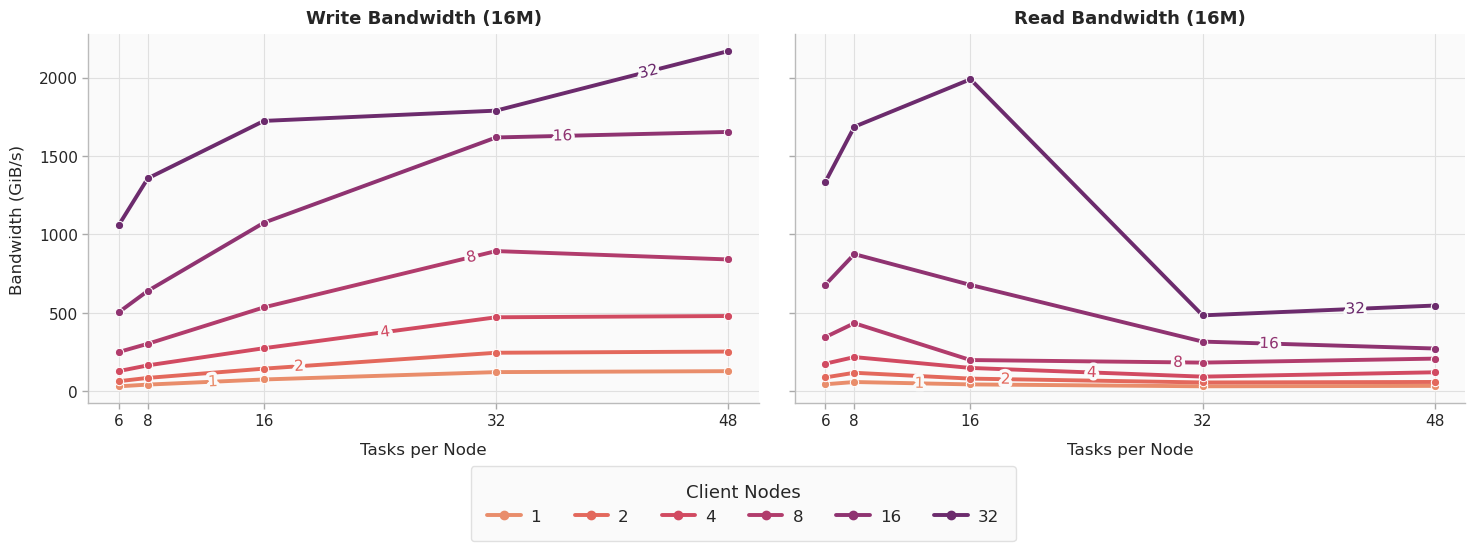

<Figure size 640x480 with 0 Axes>

In [34]:
x = "tasks_per_node"
y = "bw(GiB/s)"
hue = "nnodes"
xfer = "16M"

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              13,
    "axes.titlesize":         15,
    "axes.labelsize":         13,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        12,
    "legend.title_fontsize":  13,
    "lines.linewidth":        2.8,   # thicker lines read well at distance
})


df = full[(full['xfer_str']==xfer)]
palette = sns.color_palette("flare", len(df[hue].unique()))

col_titles = {"write": "Write Bandwidth (16M)", "read": "Read Bandwidth (16M)"}

g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                marker='o',
                facet_kws={'legend_out': False}
                )
for ax, access in zip(g.axes.flat, ["write", "read"]):

    ax.set_xticks(sorted(df[x].unique()))

    ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)

    hue_vals = sorted(df[hue].unique()) 
    lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
    for line, label in zip(lines, [str(v) for v in hue_vals]):
        line.set_label(label)
    labelLines(lines, fontsize=11, ha="left")

    # Lighten tick marks
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)


 
    
g.set_xlabels("Tasks per Node", fontsize=12, labelpad=10)
g.set_ylabels("Bandwidth (GiB/s)", fontsize=12, labelpad=10)
# g.figure.suptitle(f"Bandwidth vs Tasks per Node",  weight="bold", x = 0.5, y=1.1)
# g.figure.text(
#     0.5, 1.0,
#     f"Transfer size: {xfer}",
#     fontsize=14,
#     fontstyle="italic",
#     color="#555555",
#     ha="center",
#     va="bottom",
#     transform=g.figure.transFigure,
# )

sns.move_legend(
    g,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.15),
    # bbox_to_anchor=(1.0, 0.5),
    title="Client Nodes",
    frameon=True,
    framealpha=0.9,
    edgecolor="#dddddd",
    borderpad=1.0,
    handlelength=2.0,
    handletextpad=0.6,
)

g.figure.subplots_adjust(top=0.88)
img_path = ("../poster/diagrams/ior_bw-vs-tasks_hue-nodes_16M.svg")
plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

    access     bw(MiB/s)          IOPS  Latency  block(KiB)  xfer(KiB)  \
2    write  1.881773e+04  1.885561e+04   0.0136      131072       1024   
3     read  2.488943e+04  2.495021e+04   0.0102      131072       1024   
8    write  9.107746e+02  5.829490e+04   0.0044      131072         16   
9     read  9.620148e+02  6.157499e+04   0.0042      131072         16   
18   write  4.415488e+04  2.773137e+03   0.0903      131072      16384   
19    read  6.099447e+04  3.834645e+03   0.0653      131072      16384   
28   write  2.299125e+04  1.152351e+04   0.0221      131072       2048   
29    read  2.701317e+04  1.354280e+04   0.0187      131072       2048   
124  write  3.525448e+04  3.531932e+04   0.0143      131072       1024   
125   read  4.509269e+04  4.519468e+04   0.0113      131072       1024   
141   read  1.932088e+03  1.236664e+05   0.0041      131072         16   
140  write  1.758941e+03  1.125827e+05   0.0045      131072         16   
131   read  1.213070e+05  7.625885e+03

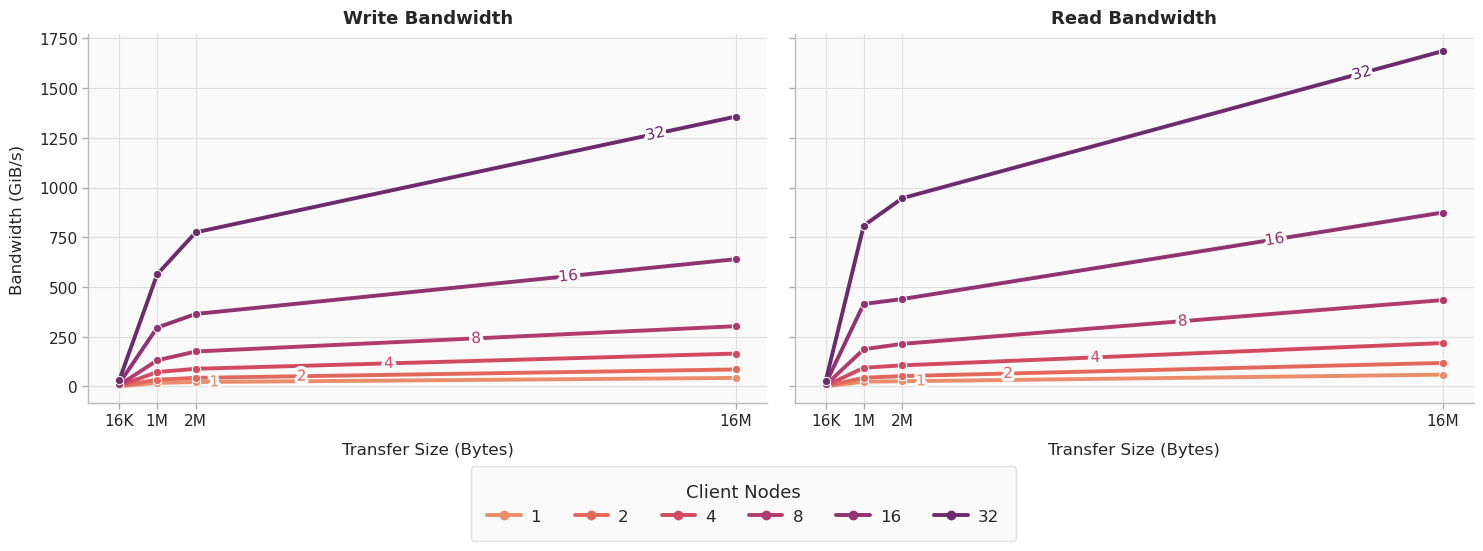

<Figure size 640x480 with 0 Axes>

In [33]:
x = "xfer(KiB)"
y = "bw(GiB/s)"
hue = "nnodes"
tasks = 8

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              13,
    "axes.titlesize":         15,
    "axes.labelsize":         13,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        12,
    "legend.title_fontsize":  13,
    "lines.linewidth":        2.8,   # thicker lines read well at distance
})


df = full[(full['tasks_per_node']==tasks)]
print(df)
palette = sns.color_palette("flare", len(df[hue].unique()))

col_titles = {"write": "Write Bandwidth", "read": "Read Bandwidth"}

g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                marker='o',
                facet_kws={'legend_out': False}
                )
for ax, access in zip(g.axes.flat, ["write", "read"]):
    ax.set_xticks(sorted(df[x].unique()))
    ax.set_xticklabels(xfer_order)

    ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)

    hue_vals = sorted(df[hue].unique()) 
    lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
    for line, label in zip(lines, [str(v) for v in hue_vals]):
        line.set_label(label)
    labelLines(lines, fontsize=11, ha="left")

    # Lighten tick marks
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)


 
    
g.set_xlabels("Transfer Size (Bytes)", fontsize=12, labelpad=10)
g.set_ylabels("Bandwidth (GiB/s)", fontsize=12, labelpad=10)
g.figure.suptitle(f"Bandwidth vs Transfer Size",  weight="bold", x = 0.5, y=1.1)


sns.move_legend(
    g,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.15),
    # bbox_to_anchor=(1.0, 0.5),
    title="Client Nodes",
    frameon=True,
    framealpha=0.9,
    edgecolor="#dddddd",
    borderpad=1.0,
    handlelength=2.0,
    handletextpad=0.6, 
)

g.figure.subplots_adjust(top=0.88)
img_path = ("../poster/diagrams/ior_bw-vs-tx_8ppn.svg")
plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

   access   bw(MiB/s)        IOPS  Latency  block(KiB)  xfer(KiB)  open(s)  \
2   write  18817.7342  18855.6122   0.0136      131072       1024   0.0069   
3    read  24889.4289  24950.2051   0.0102      131072       1024   0.0063   
8   write    910.7746  58294.8976   0.0044      131072         16   0.0063   
9    read    962.0148  61574.9924   0.0042      131072         16   0.0065   
18  write  44154.8804   2773.1365   0.0903      131072      16384   0.0068   
19   read  60994.4666   3834.6450   0.0653      131072      16384   0.0061   
28  write  22991.2495  11523.5107   0.0221      131072       2048   0.0067   
29   read  27013.1693  13542.8037   0.0187      131072       2048   0.0064   

    wr/rd(s)  close(s)  total(s)  numTasks  iter                  fromCSV  \
2     1.7378    0.0184    1.7413         8     1   rw_n-1_ppn-8_tx-1M.csv   
3     1.3133    0.0092    1.3165         8     4   rw_n-1_ppn-8_tx-1M.csv   
8    35.9749    0.0729   35.9782         8     4  rw_n-1_ppn-8_tx-

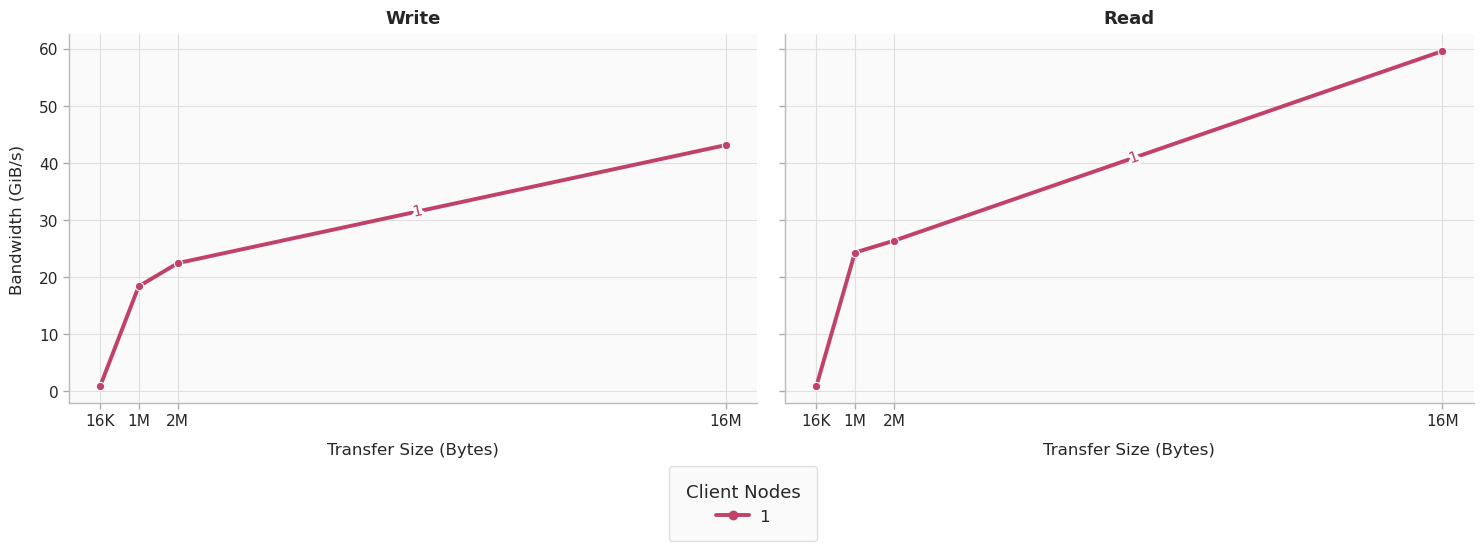

<Figure size 640x480 with 0 Axes>

In [69]:
x = "xfer(KiB)"
y = "bw(GiB/s)"
hue = "nnodes"
tasks = 8

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              13,
    "axes.titlesize":         15,
    "axes.labelsize":         13,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        12,
    "legend.title_fontsize":  13,
    "lines.linewidth":        2.8,   # thicker lines read well at distance
})


df = full[(full['tasks_per_node']==tasks) & (full['nnodes']==1)]
print(df)
palette = sns.color_palette("flare", len(df[hue].unique()))

col_titles = {"write": "Write", "read": "Read"}

g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                marker='o',
                facet_kws={'legend_out': False}
                )
for ax, access in zip(g.axes.flat, ["write", "read"]):
    ax.set_xticks(sorted(df[x].unique()))
    ax.set_xticklabels(xfer_order)

    ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)

    hue_vals = sorted(df[hue].unique()) 
    lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
    for line, label in zip(lines, [str(v) for v in hue_vals]):
        line.set_label(label)
    labelLines(lines, fontsize=11, ha="left")

    # Lighten tick marks
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)


 
    
g.set_xlabels("Transfer Size (Bytes)", fontsize=12, labelpad=10)
g.set_ylabels("Bandwidth (GiB/s)", fontsize=12, labelpad=10)
# g.figure.suptitle(f"Bandwidth vs Tasks per Node",  weight="bold", x = 0.5, y=1.1)
# g.figure.text(
#     0.5, 1.0,
#     f"Transfer size: {xfer}",
#     fontsize=14,
#     fontstyle="italic",
#     color="#555555",
#     ha="center",
#     va="bottom",
#     transform=g.figure.transFigure,
# )

sns.move_legend(
    g,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.15),
    # bbox_to_anchor=(1.0, 0.5),
    title="Client Nodes",
    frameon=True,
    framealpha=0.9,
    edgecolor="#dddddd",
    borderpad=1.0,
    handlelength=2.0,
    handletextpad=0.6, 
)

g.figure.subplots_adjust(top=0.88)
img_path = ("../poster/diagrams/ior_bw-vs-tx_8ppn.svg")
plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

/tmp/ipykernel_46146/1132905544.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xfer_order, rotation=0)


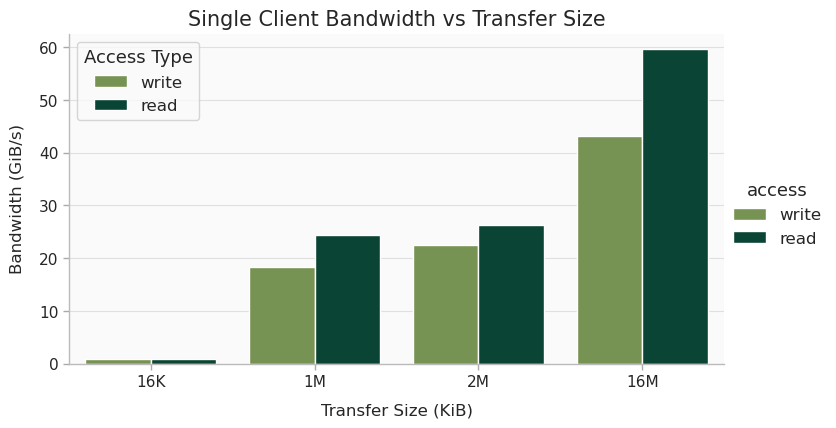

<Figure size 640x480 with 0 Axes>

In [ ]:
x = "xfer(KiB)"
y = "bw(GiB/s)"
hue = "access"
tasks = 8

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.grid":             True,
    "grid.color":            "#e0e0e0",
    "grid.linewidth":        0.8,
    "axes.facecolor":        "#fafafa",
    "figure.facecolor":      "white",
    "font.size":             13,
    "axes.titlesize":        15,
    "axes.labelsize":        13,
    "xtick.labelsize":       11,
    "ytick.labelsize":       11,
    "legend.fontsize":       12,
    "legend.title_fontsize": 13,
})

df = full[(full['tasks_per_node'] == tasks) & (full['nnodes']==1)]

n_hues = len(df[hue].unique())
palette = ['#789D4A', '#004E38']   

col_titles = {"write": "Write", "read": "Read"}

g = sns.catplot(
    data=df,
    kind="bar",
    x=x,
    y=y,
    hue=hue,
    palette=palette,
    order=sorted(df[x].unique()),                    # bars grouped by xfer size
    aspect=1.5
)

for ax in g.axes.flat:
    ax.set_xticklabels(xfer_order, rotation=0)
    # ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)

g.set_xlabels("Transfer Size (KiB)", fontsize=12, labelpad=10)
g.set_ylabels("Bandwidth (GiB/s)", fontsize=12, labelpad=10)
ax.legend(title="Access Type")

ax.set_title("Single Client Bandwidth vs Transfer Size")
g.figure.subplots_adjust(top=0.88, bottom=0.22)

# img_path = "../poster/diagrams/ior_bw-vs-tx_8ppn.svg"
# plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

/tmp/ipykernel_46146/1953910647.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xfer_order, rotation=0)


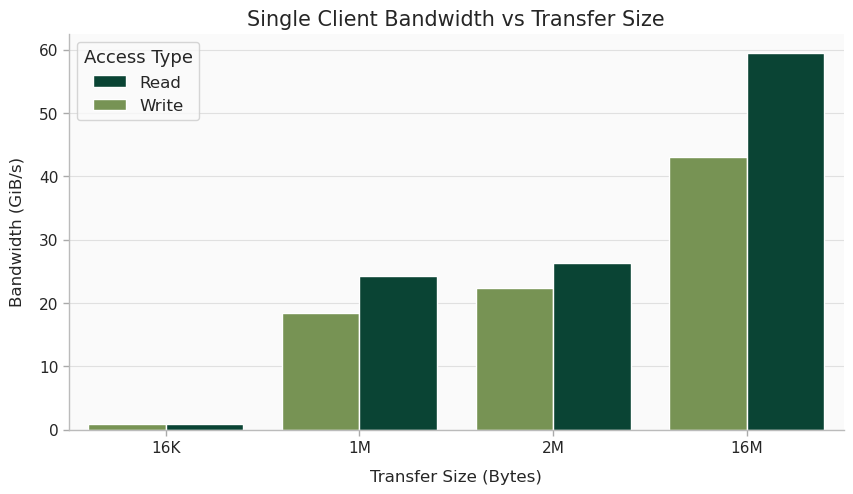

<Figure size 640x480 with 0 Axes>

In [81]:

x = "xfer(KiB)"
y = "bw(GiB/s)"
hue = "access"
tasks = 8

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.grid":             True,
    "grid.color":            "#e0e0e0",
    "grid.linewidth":        0.8,
    "axes.facecolor":        "#fafafa",
    "figure.facecolor":      "white",
    "font.size":             13,
    "axes.titlesize":        15,
    "axes.labelsize":        13,
    "xtick.labelsize":       11,
    "ytick.labelsize":       11,
    "legend.fontsize":       12,
    "legend.title_fontsize": 13,
})

df = full[(full['tasks_per_node'] == tasks) & (full['nnodes']==1)]

n_hues = len(df[hue].unique())
palette = ['#789D4A', '#004E38']   

col_titles = {"write": "Write", "read": "Read"}
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df,
    x=x,
    y=y,
    hue=hue,
    palette=palette,
    order=sorted(df[x].unique()),
    ax=ax,
)
palette = ['#789D4A', '#004E38']  
ax.set_xlabel("Transfer Size (Bytes)", fontsize=12, labelpad=10)
ax.set_ylabel("Bandwidth (GiB/s)", fontsize=12, labelpad=10)
ax.set_title("Single Client Bandwidth vs Transfer Size")
ax.set_xticklabels(xfer_order, rotation=0)
ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
for spine in ax.spines.values():
    spine.set_color("#bbbbbb")
    spine.set_linewidth(1)

handles, labels = ax.get_legend_handles_labels()
label_map = {"read": "Read", "write": "Write"}
order = ["read", "write"]
handles = [handles[labels.index(k)] for k in order if k in labels]
labels  = [label_map[k] for k in order if k in labels]
ax.legend(handles, labels, title="Access Type")

fig.subplots_adjust(top=0.88, bottom=0.22)
img_path = "../poster/diagrams/ior_bw-vs-tx_8ppn.svg"
plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

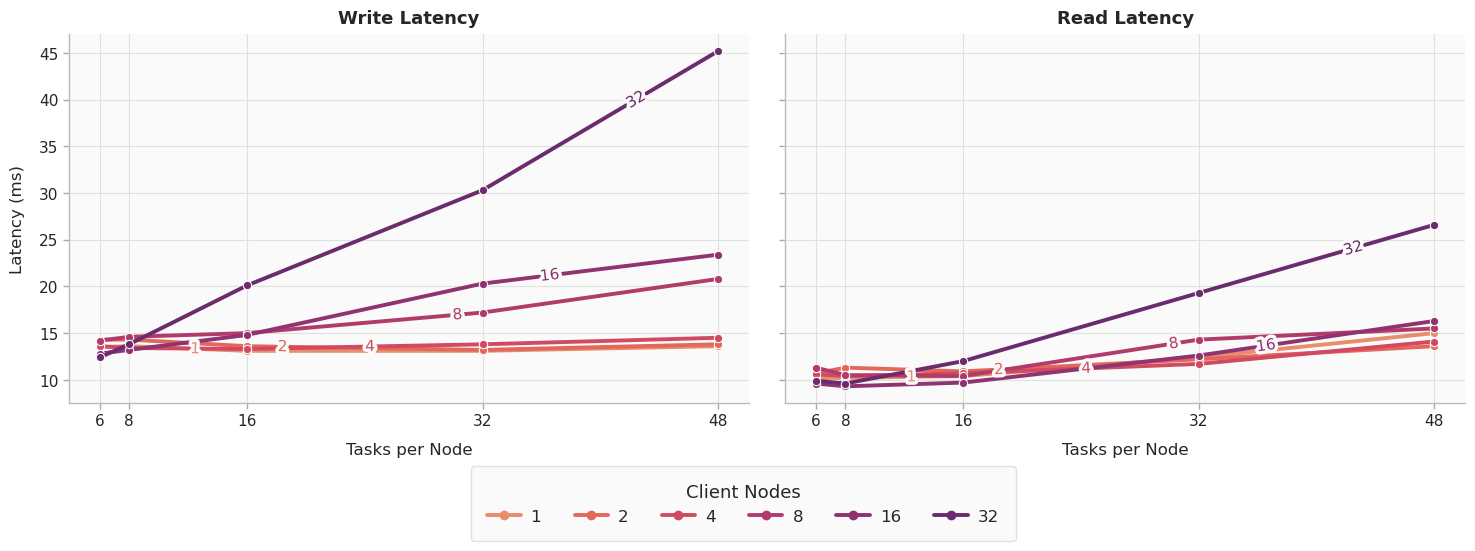

<Figure size 640x480 with 0 Axes>

In [79]:
x = "tasks_per_node"
y = "Latency(ms)"
hue = "nnodes"
xfer = "1M"

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              13,
    "axes.titlesize":         15,
    "axes.labelsize":         13,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        12,
    "legend.title_fontsize":  13,
    "lines.linewidth":        2.8,   # thicker lines read well at distance
})


df = full[(full['xfer_str']==xfer)]
palette = sns.color_palette("flare", len(df[hue].unique()))

col_titles = {"write": "Write Latency", "read": "Read Latency"}

g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                marker='o',
                facet_kws={'legend_out': False}
                )
for ax, access in zip(g.axes.flat, ["write", "read"]):

    ax.set_xticks(sorted(df[x].unique()))

    ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)

    hue_vals = sorted(df[hue].unique()) 
    lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
    for line, label in zip(lines, [str(v) for v in hue_vals]):
        line.set_label(label)
    labelLines(lines, fontsize=11, ha="left")

    # Lighten tick marks
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)


 
    
g.set_xlabels("Tasks per Node", fontsize=12, labelpad=10)
g.set_ylabels("Latency (ms)", fontsize=12, labelpad=10)
# g.figure.suptitle(f"Bandwidth vs Tasks per Node",  weight="bold", x = 0.5, y=1.1)
# g.figure.text(
#     0.5, 1.0,
#     f"Transfer size: {xfer}",
#     fontsize=14,
#     fontstyle="italic",
#     color="#555555",
#     ha="center",
#     va="bottom",
#     transform=g.figure.transFigure,
# )

sns.move_legend(
    g,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.15),
    # bbox_to_anchor=(1.0, 0.5),
    title="Client Nodes",
    frameon=True,
    framealpha=0.9,
    edgecolor="#dddddd",
    borderpad=1.0,
    handlelength=2.0,
    handletextpad=0.6,
)

g.figure.subplots_adjust(top=0.88)
img_path = ("../poster/diagrams/ior_latency.svg")
plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

## AVOID: rw_n-32_ppn-48_tx-2M.csv
# 32 nodes, 48 tasks, Transfer 2M

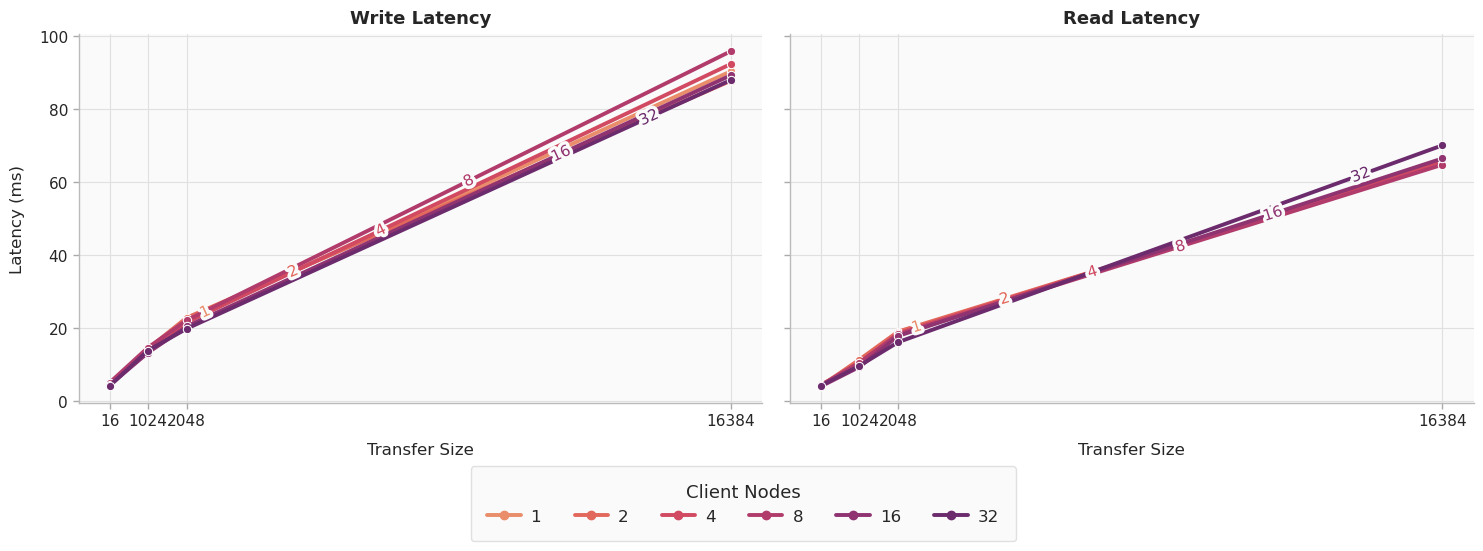

<Figure size 640x480 with 0 Axes>

In [74]:
x = "xfer(KiB)"
y = "Latency(ms)"
hue = "nnodes"
tasks = 8

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              13,
    "axes.titlesize":         15,
    "axes.labelsize":         13,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        12,
    "legend.title_fontsize":  13,
    "lines.linewidth":        2.8,   # thicker lines read well at distance
})


df = full[(full['tasks_per_node']==tasks)]
palette = sns.color_palette("flare", len(df[hue].unique()))

col_titles = {"write": "Write Latency", "read": "Read Latency"}

g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                marker='o',
                facet_kws={'legend_out': False}
                )
for ax, access in zip(g.axes.flat, ["write", "read"]):

    ax.set_xticks(sorted(df[x].unique()))

    ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)

    hue_vals = sorted(df[hue].unique()) 
    lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
    for line, label in zip(lines, [str(v) for v in hue_vals]):
        line.set_label(label)
    labelLines(lines, fontsize=11, ha="left")

    # Lighten tick marks
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)


 
    
g.set_xlabels("Transfer Size", fontsize=12, labelpad=10)
g.set_ylabels("Latency (ms)", fontsize=12, labelpad=10)
# g.figure.suptitle(f"Bandwidth vs Tasks per Node",  weight="bold", x = 0.5, y=1.1)
# g.figure.text(
#     0.5, 1.0,
#     f"Transfer size: {xfer}",
#     fontsize=14,
#     fontstyle="italic",
#     color="#555555",
#     ha="center",
#     va="bottom",
#     transform=g.figure.transFigure,
# )

sns.move_legend(
    g,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.15),
    # bbox_to_anchor=(1.0, 0.5),
    title="Client Nodes",
    frameon=True,
    framealpha=0.9,
    edgecolor="#dddddd",
    borderpad=1.0,
    handlelength=2.0,
    handletextpad=0.6,
)

g.figure.subplots_adjust(top=0.88)
img_path = ("../poster/diagrams/ior_latency.svg")
plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

## AVOID: rw_n-32_ppn-48_tx-2M.csv
# 32 nodes, 48 tasks, Transfer 2M

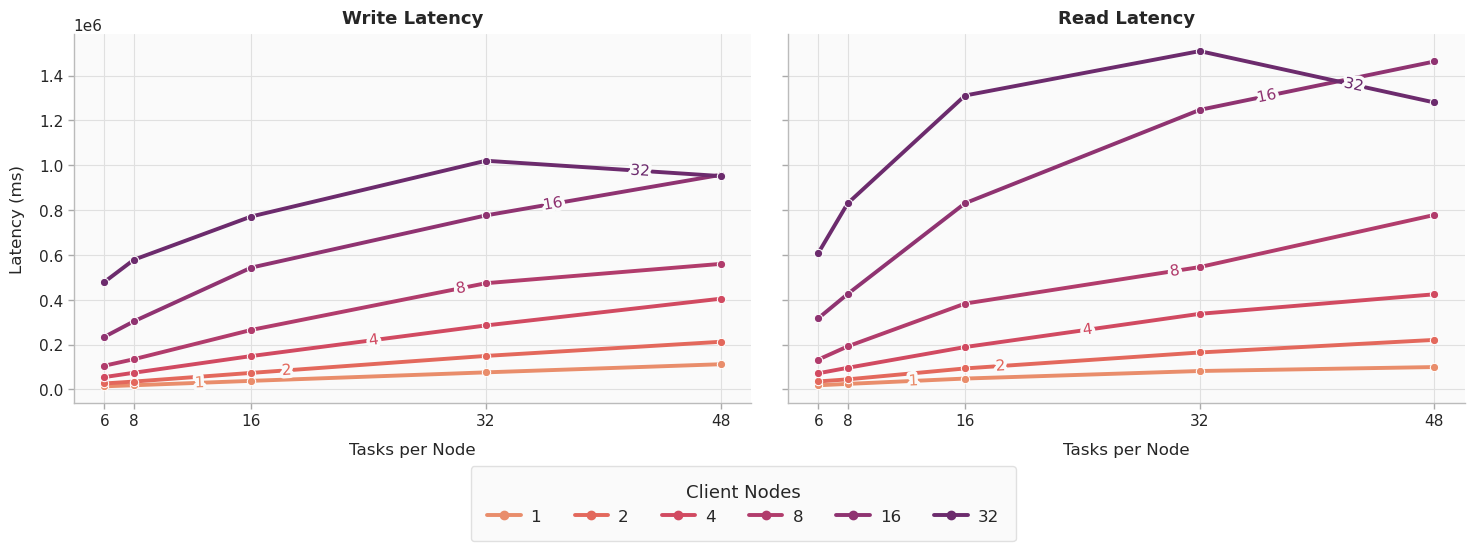

<Figure size 640x480 with 0 Axes>

In [77]:
x = "tasks_per_node"
y = "IOPS"
hue = "nnodes"
xfer = "1M"

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              13,
    "axes.titlesize":         15,
    "axes.labelsize":         13,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        12,
    "legend.title_fontsize":  13,
    "lines.linewidth":        2.8,   # thicker lines read well at distance
})


df = full[(full['xfer_str']==xfer)]
palette = sns.color_palette("flare", len(df[hue].unique()))

col_titles = {"write": "Write Latency", "read": "Read Latency"}

g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                marker='o',
                facet_kws={'legend_out': False}
                )
for ax, access in zip(g.axes.flat, ["write", "read"]):

    ax.set_xticks(sorted(df[x].unique()))

    ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)

    hue_vals = sorted(df[hue].unique()) 
    lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
    for line, label in zip(lines, [str(v) for v in hue_vals]):
        line.set_label(label)
    labelLines(lines, fontsize=11, ha="left")

    # Lighten tick marks
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)


 
    
g.set_xlabels("Tasks per Node", fontsize=12, labelpad=10)
g.set_ylabels("Latency (ms)", fontsize=12, labelpad=10)
# g.figure.suptitle(f"Bandwidth vs Tasks per Node",  weight="bold", x = 0.5, y=1.1)
# g.figure.text(
#     0.5, 1.0,
#     f"Transfer size: {xfer}",
#     fontsize=14,
#     fontstyle="italic",
#     color="#555555",
#     ha="center",
#     va="bottom",
#     transform=g.figure.transFigure,
# )

sns.move_legend(
    g,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.15),
    # bbox_to_anchor=(1.0, 0.5),
    title="Client Nodes",
    frameon=True,
    framealpha=0.9,
    edgecolor="#dddddd",
    borderpad=1.0,
    handlelength=2.0,
    handletextpad=0.6,
)

g.figure.subplots_adjust(top=0.88)
# img_path = ("../poster/diagrams/ior_latency.svg")
# plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

## AVOID: rw_n-32_ppn-48_tx-2M.csv
# 32 nodes, 48 tasks, Transfer 2M

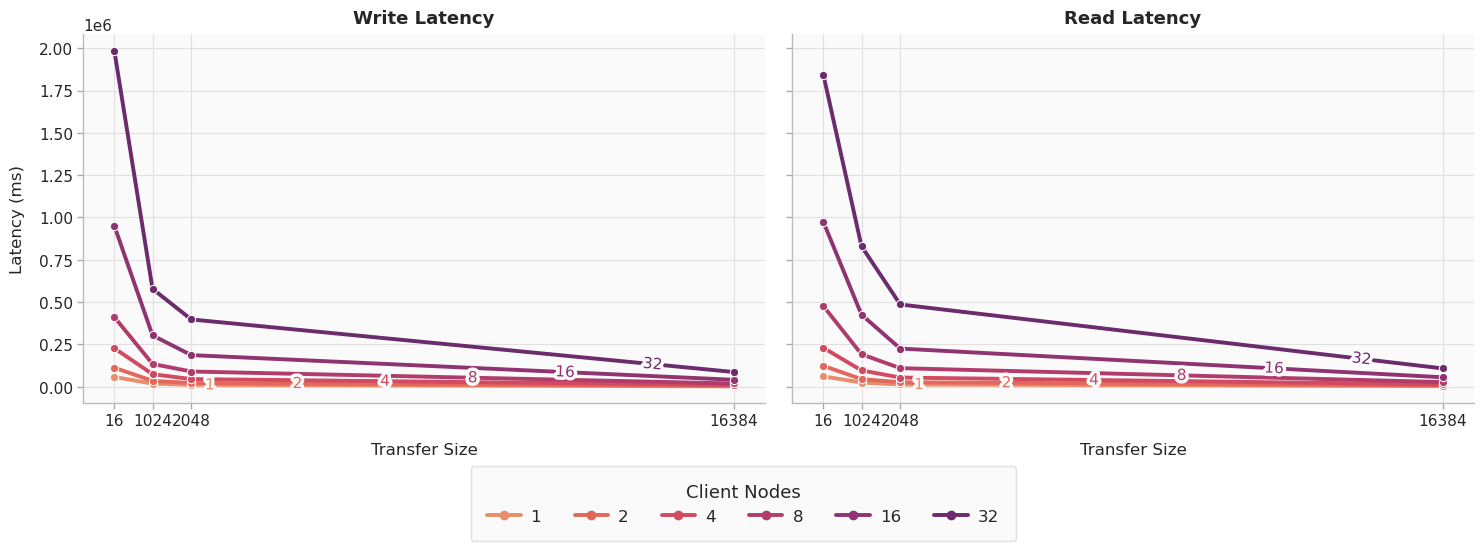

<Figure size 640x480 with 0 Axes>

In [78]:
x = "xfer(KiB)"
y = "IOPS"
hue = "nnodes"
tasks = 8

sns.set_theme(style="ticks", font="DejaVu Sans")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              13,
    "axes.titlesize":         15,
    "axes.labelsize":         13,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        12,
    "legend.title_fontsize":  13,
    "lines.linewidth":        2.8,   # thicker lines read well at distance
})


df = full[(full['tasks_per_node']==tasks)]
palette = sns.color_palette("flare", len(df[hue].unique()))

col_titles = {"write": "Write Latency", "read": "Read Latency"}

g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                marker='o',
                facet_kws={'legend_out': False}
                )
for ax, access in zip(g.axes.flat, ["write", "read"]):

    ax.set_xticks(sorted(df[x].unique()))

    ax.set_title(col_titles[access], fontsize=13, fontweight="bold", pad=8)

    hue_vals = sorted(df[hue].unique()) 
    lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
    for line, label in zip(lines, [str(v) for v in hue_vals]):
        line.set_label(label)
    labelLines(lines, fontsize=11, ha="left")

    # Lighten tick marks
    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)


 
    
g.set_xlabels("Transfer Size", fontsize=12, labelpad=10)
g.set_ylabels("Latency (ms)", fontsize=12, labelpad=10)
# g.figure.suptitle(f"Bandwidth vs Tasks per Node",  weight="bold", x = 0.5, y=1.1)
# g.figure.text(
#     0.5, 1.0,
#     f"Transfer size: {xfer}",
#     fontsize=14,
#     fontstyle="italic",
#     color="#555555",
#     ha="center",
#     va="bottom",
#     transform=g.figure.transFigure,
# )

sns.move_legend(
    g,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.15),
    # bbox_to_anchor=(1.0, 0.5),
    title="Client Nodes",
    frameon=True,
    framealpha=0.9,
    edgecolor="#dddddd",
    borderpad=1.0,
    handlelength=2.0,
    handletextpad=0.6,
)

g.figure.subplots_adjust(top=0.88)
img_path = ("../poster/diagrams/ior_latency.svg")
plt.savefig(img_path, bbox_inches="tight")
plt.show()
plt.clf()

## AVOID: rw_n-32_ppn-48_tx-2M.csv
# 32 nodes, 48 tasks, Transfer 2M

In [ ]:
x = "tasks_per_node"
y = "bw(GiB/s)"
hue = "nnodes"
style = "xfer_str"

df = full[(full['xfer_str']=='2M') | (full['xfer_str']=='16M')]
palette = sns.color_palette("magma", len(df[hue].unique()))

# marker_list = ['o', '^']
# marker_map = {xfer: marker_list[i % len(marker_list)] for i, xfer in enumerate(['2M', '16M'])}


g = sns.relplot(data=df,
                kind="line",
                x=x,
                y=y,
                hue=hue,
                # style=style,
                # style_order=['2M', '16M'],
                # markers=marker_map, 
                col='access',
                col_order=['write', 'read'],
                palette=palette,
                aspect=1.5,
                facet_kws={'legend_out': False}
                )
for ax in g.axes.flat:
    # ax.legend(title="Transfer Size (bytes)")
    ax.set_xticks(sorted(df[x].unique()))
    
g.set_xlabels("Number of Tasks per Node")
g.set_ylabels("Bandwidth (GiB/s)")
g.figure.suptitle(f"Write Bandwidth vs Tasks per Node with {nodecount}",  weight="bold", x = 0.5, y=1.01)
# plt.legend(title="Transfer Size (bytes)")

# img_path = ("graphs/ior_bandwidth/ior_bw_vs_nt_hue-xfer_col-n.svg")
# plt.savefig(img_path, bbox_inches="tight")
# readme_images.append(img_path)
plt.show()
plt.clf()

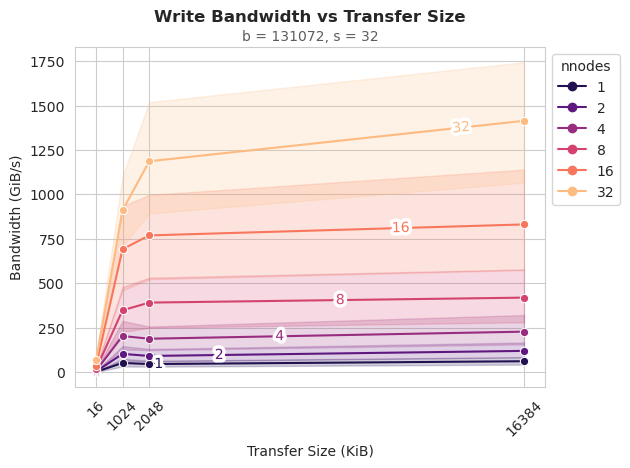

<Figure size 640x480 with 0 Axes>

In [25]:
x = "xfer(KiB)"
y = "bw(GiB/s)"
hue = "nnodes"
# hue_order = "nnodes"
df = full

hue_vals = sorted(df[hue].unique())          # consistent ordering
palette  = sns.color_palette("magma", len(hue_vals))
# palette = sns.color_palette("magma", len(df[hue].unique()))

fig, ax = plt.subplots()

ax = sns.lineplot(
        data=df, x=x, y=y, 
        hue=hue, hue_order=hue_vals,
        marker='o', palette=palette, ax=ax
)

ax.set_xticks(sorted(df[x].unique()))
plt.xticks(rotation=45)


lines = [l for l in ax.get_lines() if len(l.get_ydata())>0]
for line, label in zip(lines, [str(v) for v in hue_vals]):
    line.set_label(label)

labelLines(lines)

ax.legend(
    handles=[plt.Line2D([0], [0], color=c, marker='o', label=str(v))
             for v, c in zip(hue_vals, palette)],
    loc='upper left', bbox_to_anchor=(1, 1), title=hue
)

ax.set_xlabel("Transfer Size (KiB)")
ax.set_ylabel("Bandwidth (GiB/s)")
ax.set_title("Write Bandwidth vs Transfer Size", weight="bold", x=0.5, y=1.05)
ax.text(x=0.5, y=1.01, 
                s=f"b = {full['block(KiB)'].unique()[0]}, s = {full['segments'].unique()[0]}", 
                fontsize=10, alpha=0.75, ha='center', va='bottom', 
                transform=ax.transAxes)
# plt.savefig("graphs/ior_bandwidth/bw_vs_xfer_hue-n.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.clf() 

# IOPS Plots

/tmp/ipykernel_7279/919420976.py:8: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x=x, y=y,


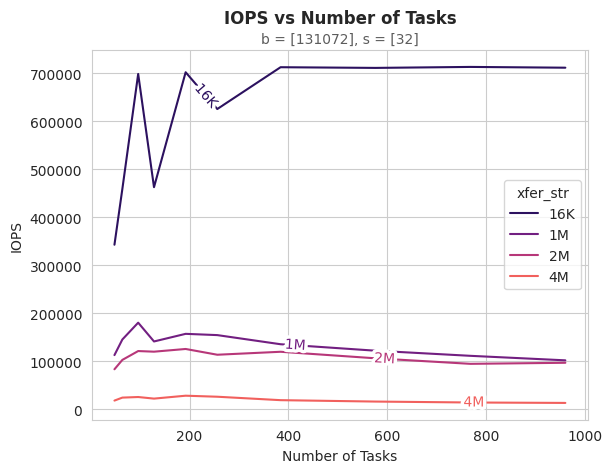

<Figure size 640x480 with 0 Axes>

In [113]:
x = "numTasks"
y = "IOPS"
hue = "xfer_str"
hue_order = xfer_order
df = full
palette = sns.color_palette("magma", len(df[hue].unique()))

ax = sns.lineplot(data=df, x=x, y=y,
                hue=hue, hue_order=hue_order,
                palette=palette
            )

lines=ax.get_lines()
lines = [l for l in lines if len(l.get_ydata())>0]
handles, labels = ax.get_legend_handles_labels()
labels = [label for label in labels if label in hue_order ]
for line, label in zip(lines, labels):
    line.set_label(label)
labelLines(lines)

ax.set_xlabel("Number of Tasks")
ax.set_ylabel("IOPS")
ax.set_title("IOPS vs Number of Tasks", weight="bold", x=0.5, y=1.05)
ax.text(x=0.5, y=1.01, 
                    s=f"b = {full['block(KiB)'].unique()}, s = {full['segments'].unique()}", 
                    fontsize=10, alpha=0.75, ha='center', va='bottom', 
                    transform=ax.transAxes)

img_path = "graphs/ior_iops/ior_iops_vs_nt_hue-xfer.svg"
plt.savefig(img_path, bbox_inches="tight")
readme_images.append(img_path)
plt.show()
plt.clf() 


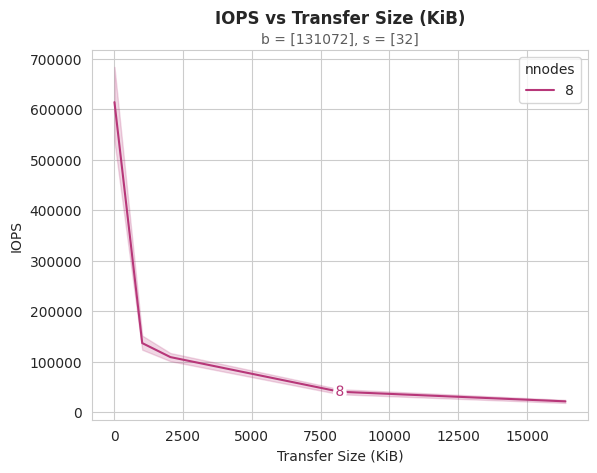

<Figure size 640x480 with 0 Axes>

In [114]:
x = "xfer(KiB)"
y = "IOPS"
hue = "nnodes"
hue_order = df['nnodes'].unique().tolist()
hue_order.sort()
df = full
palette = sns.color_palette("magma", len(df[hue].unique()))

ax = sns.lineplot(data=df, x=x, y=y,
                hue=hue, hue_order=hue_order,
                palette=palette
            )

lines=ax.get_lines()
lines = [l for l in lines if len(l.get_ydata())>0]
handles, labels = ax.get_legend_handles_labels()
labels = [label for label in labels if label in str(hue_order) ]
for line, label in zip(lines, labels):
    line.set_label(label)
labelLines(lines)

ax.set_xlabel("Transfer Size (KiB)")
ax.set_ylabel("IOPS")
ax.set_title("IOPS vs Transfer Size (KiB)", weight="bold", x=0.5, y=1.05)
ax.text(x=0.5, y=1.01, 
                    s=f"b = {full['block(KiB)'].unique()}, s = {full['segments'].unique()}", 
                    fontsize=10, alpha=0.75, ha='center', va='bottom', 
                    transform=ax.transAxes)

img_path = "graphs/ior_iops/ior_iops_vs_xfer_hue-n.svg"
plt.savefig(img_path, bbox_inches="tight")
readme_images.append(img_path)
plt.show()
plt.clf() 

# Latency Plots

/tmp/ipykernel_7279/3785043489.py:8: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x=x, y=y,


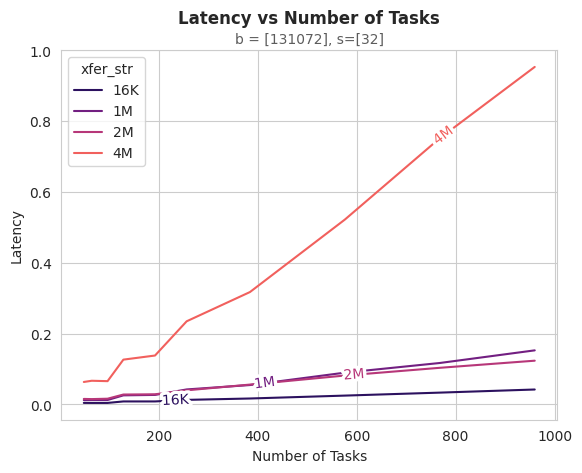

<Figure size 640x480 with 0 Axes>

In [115]:
x = "numTasks"
y = "Latency"
hue = "xfer_str"
hue_order = xfer_order
df = full
palette = sns.color_palette("magma", len(df[hue].unique()))

ax = sns.lineplot(data=df, x=x, y=y,
                hue=hue, hue_order=hue_order,
                palette=palette
            )

lines=ax.get_lines()
lines = [l for l in lines if len(l.get_ydata())>0]
handles, labels = ax.get_legend_handles_labels()
labels = [label for label in labels if label in hue_order ]
for line, label in zip(lines, labels):
    line.set_label(label)
labelLines(lines)

ax.set_xlabel("Number of Tasks")
ax.set_ylabel("Latency")
ax.set_title("Latency vs Number of Tasks", weight="bold", x=0.5, y=1.05)
ax.text(x=0.5, y=1.01, 
                    s=f"b = {full['block(KiB)'].unique()}, s={full['segments'].unique()}", 
                    fontsize=10, alpha=0.75, ha='center', va='bottom', 
                    transform=ax.transAxes)

img_path = "graphs/ior_latency/ior_lat_vs_nt_hue-xfer.svg"
plt.savefig(img_path, bbox_inches="tight")
readme_images.append(img_path)
plt.show()
plt.clf() 


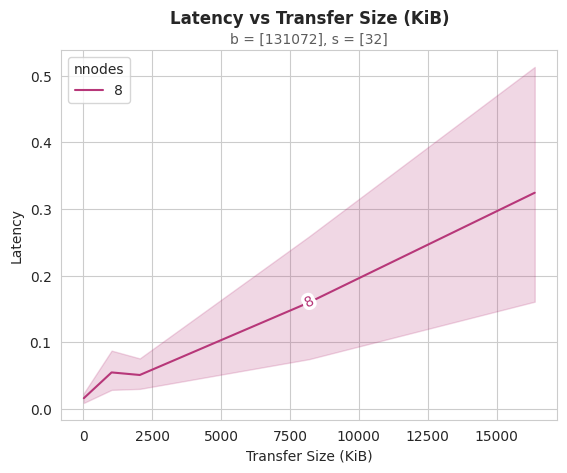

<Figure size 640x480 with 0 Axes>

In [116]:
x = "xfer(KiB)"
y = "Latency"
hue = "nnodes"
hue_order = df['nnodes'].unique().tolist()
hue_order.sort()
df = full
palette = sns.color_palette("magma", len(df[hue].unique()))

ax = sns.lineplot(data=df, x=x, y=y,
                hue=hue, hue_order=hue_order,
                palette=palette
            )

lines=ax.get_lines()
lines = [l for l in lines if len(l.get_ydata())>0]
handles, labels = ax.get_legend_handles_labels()
labels = [label for label in labels if label in str(hue_order) ]
for line, label in zip(lines, labels):
    line.set_label(label)
labelLines(lines)

ax.set_xlabel("Transfer Size (KiB)")
ax.set_ylabel("Latency")
ax.set_title("Latency vs Transfer Size (KiB)", weight="bold", x=0.5, y=1.05)
ax.text(x=0.5, y=1.01, 
                    s=f"b = {full['block(KiB)'].unique()}, s = {full['segments'].unique()}", 
                    fontsize=10, alpha=0.75, ha='center', va='bottom', 
                    transform=ax.transAxes)

img_path = "graphs/ior_latency/ior_lat_vs_xfer_hue-n.svg"
plt.savefig(img_path, bbox_inches="tight")
readme_images.append(img_path)
plt.show()
plt.clf() 

In [117]:
# palette = sns.color_palette("magma", len(df["iter"].unique()))
# ax = sns.lineplot(
#                 data=df,
#                 x="xfer(KiB)",
#                 y="bw(MiB/s)",
#                 hue="iter",
#                 # style="rand_seq_type", dashes=dashes,
#                 # marker='o',
#                 # hue_order=hue_order,
#                 # order=bs_order,
#                 # palette=palette
#             )
# ax.set_xlabel("Number of Tasks")
# ax.set_ylabel("Bandwidth (MiB/s)")
# ax.set_title("Bandwidth vs Number of Tasks (all iter)", weight="bold", x=0.5, y=1.05)
# plt.show()
# plt.clf() 

In [118]:
copy_paste_str = "## Images from plot_ior.ipynb:\n"
for img_path in readme_images:
    copy_paste_str += f'![{img_path}]({img_path})\n'
print(copy_paste_str)

## Images from plot_ior.ipynb:
![graphs/ior_bandwidth/bw_vs_nt_hue-xfer.svg](graphs/ior_bandwidth/bw_vs_nt_hue-xfer.svg)
![graphs/ior_bandwidth/ior_bw_vs_nt_hue-xfer_col-n.svg](graphs/ior_bandwidth/ior_bw_vs_nt_hue-xfer_col-n.svg)
![graphs/ior_iops/ior_iops_vs_nt_hue-xfer.svg](graphs/ior_iops/ior_iops_vs_nt_hue-xfer.svg)
![graphs/ior_iops/ior_iops_vs_xfer_hue-n.svg](graphs/ior_iops/ior_iops_vs_xfer_hue-n.svg)
![graphs/ior_latency/ior_lat_vs_nt_hue-xfer.svg](graphs/ior_latency/ior_lat_vs_nt_hue-xfer.svg)
![graphs/ior_latency/ior_lat_vs_xfer_hue-n.svg](graphs/ior_latency/ior_lat_vs_xfer_hue-n.svg)



In [119]:

lcm = 24
for i in range(10):
    print(lcm*i)

0
24
48
72
96
120
144
168
192
216
